In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지

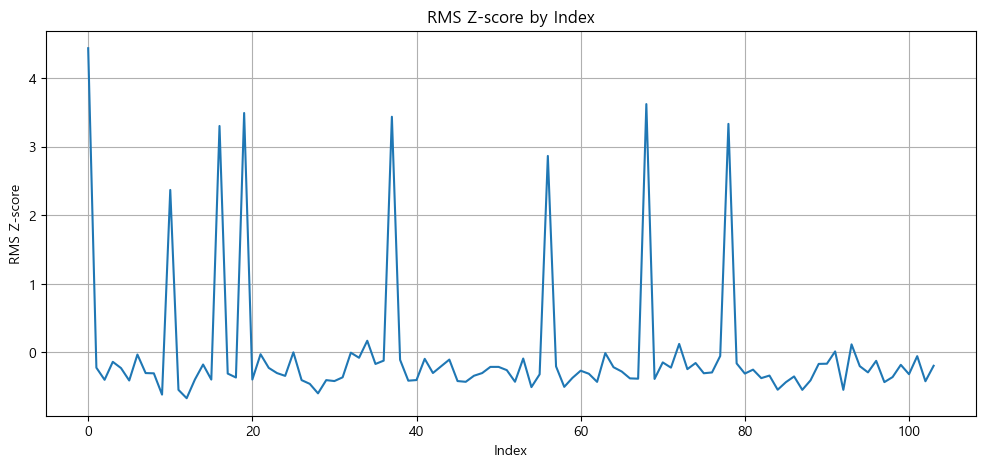

In [11]:
df = pd.read_csv('25_mimii_features.csv')
rms_zscore = (df['rms'] - df['rms'].mean()) / df['rms'].std()
plt.figure(figsize=(12, 5))
plt.plot(rms_zscore.index, rms_zscore)
plt.xlabel('Index')
plt.ylabel('RMS Z-score')
plt.title('RMS Z-score by Index')
plt.grid(True)
plt.show()

In [12]:
df = pd.read_csv('26_mimii_features.csv')
print(df.shape)
abnormal_count = (df['label'] == 1).sum()
normal_count = (df['label'] == 0).sum()
print(f'정상 {normal_count}, 이상 {abnormal_count}')

(220, 4)
정상 180, 이상 40


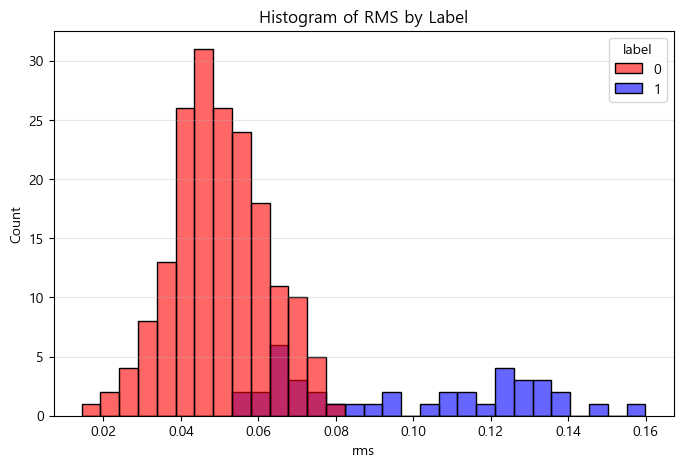

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='rms',
    hue='label',
    hue_order=[0, 1],
    palette={0: 'red', 1: 'blue'},
    bins=30,
    multiple='layer',
    alpha=0.6
)

plt.xlabel('rms')
plt.ylabel('Count')
plt.title('Histogram of RMS by Label')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [14]:
df = pd.read_csv('26_mimii_features.csv')
normal_count = (df['label'] == 0).sum()
print(f'정상 {normal_count}개')

columns = ['rms', 'spectral_centroid', 'zero_crossing_rate']

for column in columns:
    avg = df[df['label'] == 1][column].mean()
    std = df[df['label'] == 1][column].std()

    print(f'{column}: avg = {avg:.3f}, std = {std:.3f}')

정상 180개
rms: avg = 0.099, std = 0.031
spectral_centroid: avg = 2480.015, std = 361.011
zero_crossing_rate: avg = 0.119, std = 0.028


In [15]:
df2 = pd.read_csv('26_mimii_features.csv')
df_ok = df2[df2['label']==0]
df_ok['z-score'] = (df_ok['rms'] - df_ok['rms'].mean()) / df_ok['rms'].std()
df_ok = df_ok.sort_values(by='z-score', ascending=False)

print(df_ok['z-score'].max())

2.2879738320208296


C:\Users\user\AppData\Local\Temp\ipykernel_14164\3246686840.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ok['z-score'] = (df_ok['rms'] - df_ok['rms'].mean()) / df_ok['rms'].std()


In [16]:
df = pd.read_csv('26_mimii_features.csv')
df['zscore'] = (df['rms'] - df['rms'].mean()) / df['rms'].std()

print(df['zscore'].max())

3.9774742356388457


In [17]:
normal = df[df['label'] == 0]
mu, sd = normal['rms'].mean(), normal['rms'].std()
df['z_rms'] = (df['rms'] -mu) / sd
top = df.sort_values('z_rms', ascending=False)[['rms', 'z_rms', 'label']].head(3)
print(top.round(2).to_string(index=False))

 rms  z_rms  label
0.16   9.01      1
0.15   7.92      1
0.14   7.21      1


In [18]:
df = pd.read_csv('26_mimii_features.csv')
df['zscore_abs'] = abs((df['rms'] - df['rms'].mean()) / df['rms'].std())
df['is_normal'] = df[df['zscore_abs'] > 3]['zscore_abs']
count_2 = (df['zscore_abs'] > 2).sum()
count_3 = len(df[df['zscore_abs'] > 3])



In [19]:
# 실습5

df['z_abs'] = df['z_rms'].abs()
df['is_anomal'] = df['z_abs'] > 3
print('임계값3:', int(df['is_anomaly'].sum()))        
print('임계값2:', int((df['z_abs'] > 2).sum()))   

KeyError: 'z_rms'

In [ ]:

normal = df[df['label'] == 0]

is_any = pd.Series(False, index=df.index)

for f in ['rms', 'spectral_centroid', 'zero_crossing_rate']:
    z = (df[f] - normal[f].mean()) / normal[f].std()
    is_any = is_any | (np.abs(z) > 3)


rms_z = (df['rms'] - normal['rms'].mean()) / normal['rms'].std()
is_rms = np.abs(rms_z) > 3

print('rms 단독 이상:', int(is_rms.sum()))
print('종합 이상:', int(is_any.sum()))

rms 단독 이상: 23
종합 이상: 39


In [ ]:
df = pd.read_csv('26_mimii_features.csv')
xnormal = df[df['label'] == 1].copy()

columns = ['rms', 'spectral_centroid', 'zero_crossing_rate']

for column in columns:
    xnormal[f'z_{column}'] =(df[column] - xnormal[column].mean()) / xnormal[column].std()
    
    print(abs(xnormal[f'z_{column}']).sort_values(ascending=False).head(3))





70     1.998485
108    1.566168
215    1.456778
Name: z_rms, dtype: float64
157    2.501353
81     1.595202
70     1.476452
Name: z_spectral_centroid, dtype: float64
164    1.891968
159    1.882938
26     1.810521
Name: z_zero_crossing_rate, dtype: float64


In [ ]:
anomaly_top = (df.loc[df['is_anomaly']].nlargest(3, 'z_abs'))

for sample_id, sample in anomaly_top.iterrows():
    trend = '높은 방향' if sample['z_rms'] >= 0 else '낮은 방향'
    deviation = sample['z_abs']

    print(
        f'샘플 {sample_id}: '
        f'소리 세기가 표준편차 기준 {deviation:.1f}배 '
        f'{trend}으로 벗어남 → 점검 권장'
    )

In [ ]:
import sklearn as sk

In [ ]:
from sklearn.ensemble import  IsolationForest

In [21]:
X=df[['rms', 'spectral_centroid', 'zero_crossing_rate']]

iso = IsolationForest(contamination=0.18, random_state=42)
iso.fit(X)

pred = iso.predict(X)

print(pred)

[ 1  1  1  1  1  1 -1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1
  1 -1 -1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1 -1  1  1
  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1
 -1  1 -1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1 -1 -1 -1  1  1  1
  1  1  1  1  1 -1  1  1 -1  1  1 -1 -1  1  1  1  1  1  1  1  1  1  1 -1
  1  1  1  1  1  1  1  1  1 -1  1  1  1  1 -1  1  1  1  1  1  1  1 -1  1
  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1  1 -1  1  1  1 -1 -1  1  1  1
  1  1 -1  1 -1  1  1 -1 -1  1  1  1  1  1  1 -1  1  1  1 -1  1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1
  1  1 -1  1]


In [24]:
x = df[['rms', 'spectral_centroid', 'zero_crossing_rate']]

model = IsolationForest(contamination= 0.05, random_state=42)

model.fit(x)

df['이상판정'] = model.predict(x)

print(df['이상판정'].value_counts())

이상판정
 1    209
-1     11
Name: count, dtype: int64


In [ ]:
df = pd.read_csv('26_mimii_features.csv')
model = IsolationForest(contamination= 0.05, random_state=42)

model.fit(x)

df['이상판정'] = model.predict(x)

In [ ]:
df = pd.read_csv('26_mimii_features.csv')
x = df[['rms', 'spectral_centroid', 'zero_crossing_rate']]

model = IsolationForest(contamination=0.18, random_state=42)
model.fit(x)

pred = model.predict(x)
df['pred_anom'] = (pred == -1).astype(int)

print('예측 이상 개수:', df['pred_anom'].sum())


예측 이상 개수: 40
정답 이상 개수: 180


In [27]:
table = pd.crosstab(
    df['label'],
    df['pred_anom'],
    rownames=['실제 label'],
    colnames=['예측 pred_anom']
)

print(table)

true_anomaly_detected = ((df['label'] == 1) & (df['pred_anom'] == 1)).sum()

print('실제 이상을 이상으로 예측한 개수:', true_anomaly_detected)

예측 pred_anom    0   1
실제 label             
0             166  14
1              14  26
실제 이상을 이상으로 예측한 개수: 26


In [ ]:
df['score'] = model.score_samples(x)

In [34]:
df = pd.read_csv('26_mimii_features.csv')
x = df[['rms', 'spectral_centroid', 'zero_crossing_rate']]

model = IsolationForest(contamination=0.18, random_state=42)

model.fit(x)

pred = model.predict(x)

df['score'] = model.score_samples(x)
df['decision'] = model.decision_function(x)

df['pred_anom'] = (pred == -1).astype(int)

print('예측 이상 개수:', df['pred_anom'].sum())

table = pd.crosstab(
    df['label'],
    df['pred_anom'],
    rownames=['실제 label'],
    colnames=['예측 pred_anom']
)

print(table)

true_anomaly_detected = ((df['label'] == 1) & (df['pred_anom'] == 1)).sum()

print('실제 이상을 이상으로 예측한 개수:', true_anomaly_detected)
print(df['decision'])


예측 이상 개수: 40
예측 pred_anom    0   1
실제 label             
0             166  14
1              14  26
실제 이상을 이상으로 예측한 개수: 26
0      0.094382
1      0.104356
2      0.126779
3      0.118790
4      0.068908
         ...   
215    0.004180
216    0.114150
217    0.124996
218   -0.072407
219    0.101998
Name: decision, Length: 220, dtype: float64
